<a href="https://colab.research.google.com/github/ab23ms233/blogs/blob/main/standardization/feature_scaling_standardization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the dataset

We import the dataset from `purchase_data.csv` as a `pandas DataFrame`

In [ ]:
import pandas as pd

df = pd.read_csv("purchase_data.csv")
df.sample(5, random_state=30)

,Age (in years),Salary (in Rs.),Purchased
20,44,63961,0
91,60,83028,1
34,65,99492,1
52,37,111766,1
8,28,67157,1


# Splitting data

We split the dataset into training and testing sets. **Purchased** column is our test variable, whereas **Age** and **Salary** are our training variables.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Purchased'])
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardization

$$z = \frac{x - \mu}{\sigma}$$

where,

z = standardized value

x = current value

$\mu$ = mean of column

$\sigma$ = standard deviation of column

1. We apply standardization on the input columns only - **Age** and **Salary**. The **target column (Purchased)** is not changed.

2. We calculate $\mu$ and $\sigma$ of `X_train` and standardize the columns.

3. We use the $\mu$ and $\sigma$ calculated from `X_train` and use that to standardize `X_test`. This is an **IMPORTANT** point! We do not use $\mu$ and $\sigma$ of `X_test`, as that would leak information from the testing set into the data. In simple words, in a real-world scenario, the algorithm won't have access to the testing data beforehand, hence we can't use any information from it during training.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

## Properties of standardized features

1. $\mu = 0$

2. $\sigma = 1$

In [ ]:
type(X_train_std)

numpy.ndarray

In [ ]:
import numpy as np

df_std = pd.DataFrame(X_train_std, columns=["Age_std", "Salary_std"])
np.round(df_std.describe(), 2)

,Age_std,Salary_std
count,80.00,80.00
mean,0.00,-0.00
std,1.01,1.01
min,-1.82,-1.67
25%,-0.71,-0.83
50%,0.01,-0.03
75%,0.85,0.75
max,1.63,1.91


In [ ]:
type(y_train)

pandas.core.series.Series

# Visualizing distribution of data

We visualize data using:
1. Scatterplot
2. Kernel density estimate

We use the libraries `matplotlib` and `seaborn` for visualization.

## Scatterplot

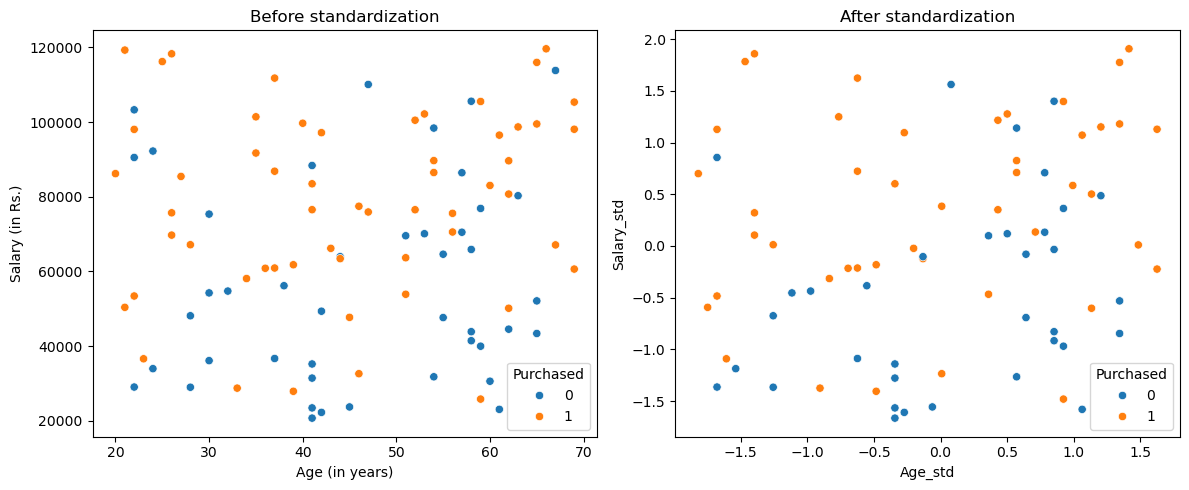

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Adding purchased column to df_std
df_std["Purchased"] = y_train.values

fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

# Before standardization
sns.scatterplot(data=df, x='Age (in years)', y='Salary (in Rs.)', ax=axes[0], hue='Purchased')
axes[0].set_title('Before standardization')

# After standardization
sns.scatterplot(data=df_std, x='Age_std', y='Salary_std', ax=axes[1], hue='Purchased')
axes[1].set_title('After standardization')

plt.tight_layout()
plt.show()

## Kernel density estimate (KDE)

The shape of the distribution remains the same, however, the scale and position ($\mu$) is shifted.

### Age

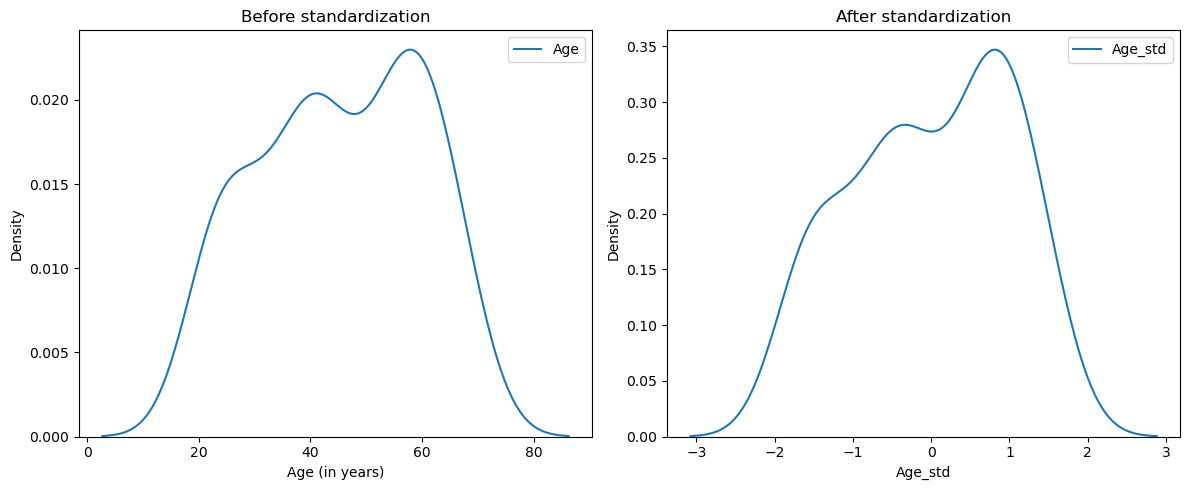

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

sns.kdeplot(df['Age (in years)'], ax=axes[0], label='Age')
sns.kdeplot(df_std['Age_std'], ax=axes[1], label='Age_std')

axes[0].set_title("Before standardization")
axes[1].set_title("After standardization")
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()


### Salary

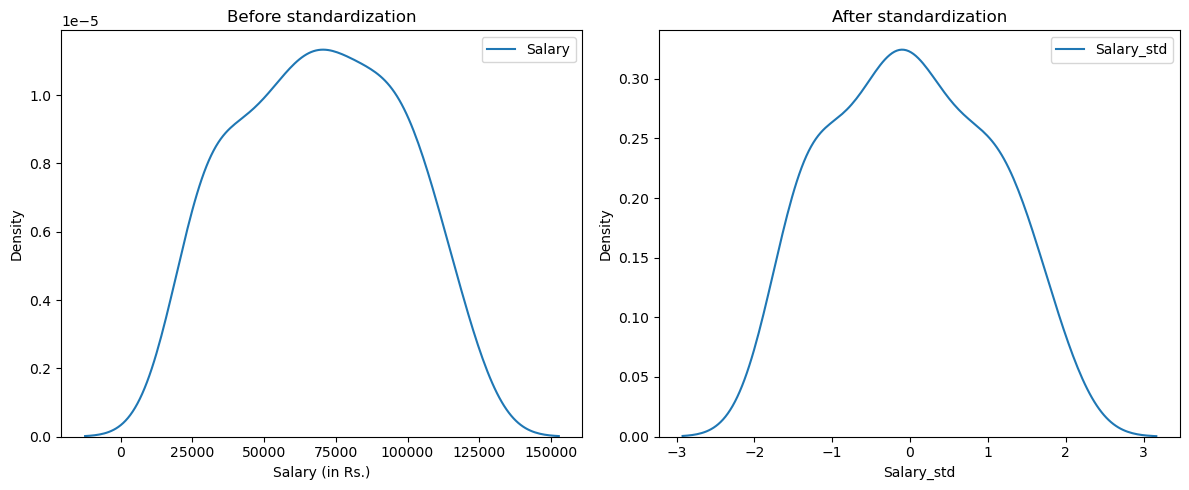

In [ ]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 5))

sns.kdeplot(df['Salary (in Rs.)'], ax=axes[0], label='Salary')
sns.kdeplot(df_std['Salary_std'], ax=axes[1], label='Salary_std')

axes[0].set_title("Before standardization")
axes[1].set_title("After standardization")
axes[0].legend()
axes[1].legend()

plt.tight_layout()
plt.show()

# Practical example: Logistic regression

We will implement the **Logistic Regression** algorithm on our dataset for classification and check what impact standardization has in terms of accuracy and convergence.

## Without standardization

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

# Applying logistic regression
lr = LogisticRegression()
lr.fit(X_train, y_train)

# Making predictions
predictions = lr.predict(X_test)

# Calculating accuracy and iterations
print(f"Accuracy: {accuracy_score(y_test, predictions): 0.4f}")
print(f"Iterations: {lr.n_iter_}")


Accuracy:  0.7000
Iterations: [58]


## With standardization

In [ ]:
lr_scaled = LogisticRegression()
lr_scaled.fit(X_train_std, y_train)

predictions = lr_scaled.predict(X_test_std)

print(f"Accuracy: {accuracy_score(y_test, predictions): 0.4f}")
print(f"Iterations: {lr_scaled.n_iter_}")


Accuracy:  0.7000
Iterations: [4]
